# 1. Imports and Setup
This cell imports essential libraries for deep learning and visualization:
- `torch` & `torch.nn`: Core PyTorch library and neural network modules.
- `torch.optim`: Optimization algorithms (e.g., Adam).
- `torch.utils.data`: Dataset management utilities (`DataLoader`, `random_split`).
- `torchvision.datasets` & `transforms`: Standard computer vision datasets and data preprocessing transformations.
- `device`: Automatically selects GPU (`cuda`) if available, otherwise falls back to `cpu`.
- `transform`: Converts raw PIL images to PyTorch tensors and normalizes grayscale pixel values using MNIST dataset mean (`0.1307`) and standard deviation (`0.3081`).

In [2]:
import matplotlib.pyplot as plt
import torch 
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

generator = torch.Generator().manual_seed(42)

# 2. Dataset Loading and Train/Validation Split
This cell handles dataset ingestion and splitting:
- `datasets.MNIST(...)`: Downloads and loads the official MNIST handwritten digit dataset (60,000 train images, 10,000 test images).
- `random_split(...)`: Splits the 60,000 training images into 54,000 for model training and 6,000 for validation to monitor generalizability during training.

In [3]:
train_dataset = datasets.MNIST(
    root = "../../Datasets",
    train = True,
    transform=transform,
    download=True
)

test_dataset = datasets.MNIST(
    root = "../../Datasets",
    train = False,
    transform=transform,
    download=True
)

train_dataset, val_dataset = random_split(
    train_dataset,
    [54000, 6000],
    generator=generator
)

# 3. DataLoaders Creation
This cell initializes PyTorch DataLoaders:
- `train_loader`: Shuffles and feeds training samples in mini-batches of size `64`.
- `val_loader`: Feeds validation samples in mini-batches of size `64` without shuffling.
- `test_loader`: Feeds test samples in larger batches of size `1000` for high-throughput evaluation without gradient overhead.

In [4]:
train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    batch_size=64
)

val_loader = DataLoader(
    val_dataset,
    shuffle=False,
    batch_size=64
)

test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    batch_size=1000
)

# 4. CNN Architecture Definition
This cell constructs the 2D Convolutional Neural Network class (`CNN`):
- `self.conv1` & `self.conv2`: Extract 2D spatial feature maps using 3x3 kernels.
- `self.relu1`, `self.relu2`, `self.relu3`: Introduce non-linear activations.
- `self.pool1` & `self.pool2`: Downsample spatial dimensions by half (from 28x28 to 14x14, then to 7x7) using Max Pooling.
- `self.flatten`: Reshapes 3D feature tensors into 1D feature vectors.
- `self.fc1` (`nn.LazyLinear`): Automatically infers input dimensions (`64 * 7 * 7 = 3136`) and projects to 128 hidden units.
- `self.fc2`: Final linear layer producing 10 raw logits corresponding to digit classes (0–9).

In [5]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.flatten = nn.Flatten()

        self.fc1 = nn.LazyLinear(128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        x = self.flatten(x)

        x = self.fc1(x)
        x = self.relu3(x)
        x = self.fc2(x)

        return x


model = CNN().to(device)

# 5. Loss Function and Optimizer
This cell defines the training objectives:
- `criterion = nn.CrossEntropyLoss()`: Combines `LogSoftmax` and Negative Log-Likelihood Loss for multi-class classification.
- `optimizer = optim.Adam(...)`: Uses adaptive moment estimation with learning rate `0.001` for efficient gradient updates.

In [6]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

# 6. Model Training and Validation Loop
This cell executes training across 5 epochs:
- `model.train()`: Enables training mode.
- `optimizer.zero_grad()`: Clears accumulated gradients before each step.
- `loss.backward()`: Computes gradients via backpropagation.
- `optimizer.step()`: Updates network weights.
- `model.eval()` & `torch.no_grad()`: Evaluates model performance on validation data without gradient tracking to prevent data leakage and save memory.

In [7]:
epochs = 5

for epoch in range(epochs):

    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        predicted = outputs.argmax(dim=1)

        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_loss /= len(train_loader)
    train_accuracy = train_correct / train_total


    model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            predicted = outputs.argmax(dim=1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss /= len(val_loader)
    val_accuracy = val_correct / val_total


    print(
        f"Epoch {epoch+1:02d}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )


Epoch 01/5 | Train Loss: 0.1422 | Train Acc: 0.9562 | Val Loss: 0.0546 | Val Acc: 0.9848
Epoch 02/5 | Train Loss: 0.0434 | Train Acc: 0.9867 | Val Loss: 0.0454 | Val Acc: 0.9863
Epoch 03/5 | Train Loss: 0.0296 | Train Acc: 0.9909 | Val Loss: 0.0408 | Val Acc: 0.9873
Epoch 04/5 | Train Loss: 0.0217 | Train Acc: 0.9931 | Val Loss: 0.0366 | Val Acc: 0.9887
Epoch 05/5 | Train Loss: 0.0155 | Train Acc: 0.9954 | Val Loss: 0.0516 | Val Acc: 0.9875


# 7. Final Model Evaluation on Unseen Test Data
This cell evaluates the trained model on 10,000 unseen test images to compute final test loss and overall classification accuracy.

In [10]:
model.eval()

test_loss = 0.0
test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)
        test_loss += loss.item()

        predicted = outputs.argmax(dim=1)

        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

test_loss /= len(test_loader)
test_accuracy = test_correct / test_total

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.0414
Test Accuracy: 0.9878


# 8. Misclassification Analysis and Visualization
This cell extracts and plots misclassified images:
- Collects samples where `predicted != true_label`.
- Un-normalizes pixel values (`image * 0.3081 + 0.1307`) to restore displayable grayscale range.
- Renders a 3x4 grid displaying true vs predicted digit labels to analyze failure cases.

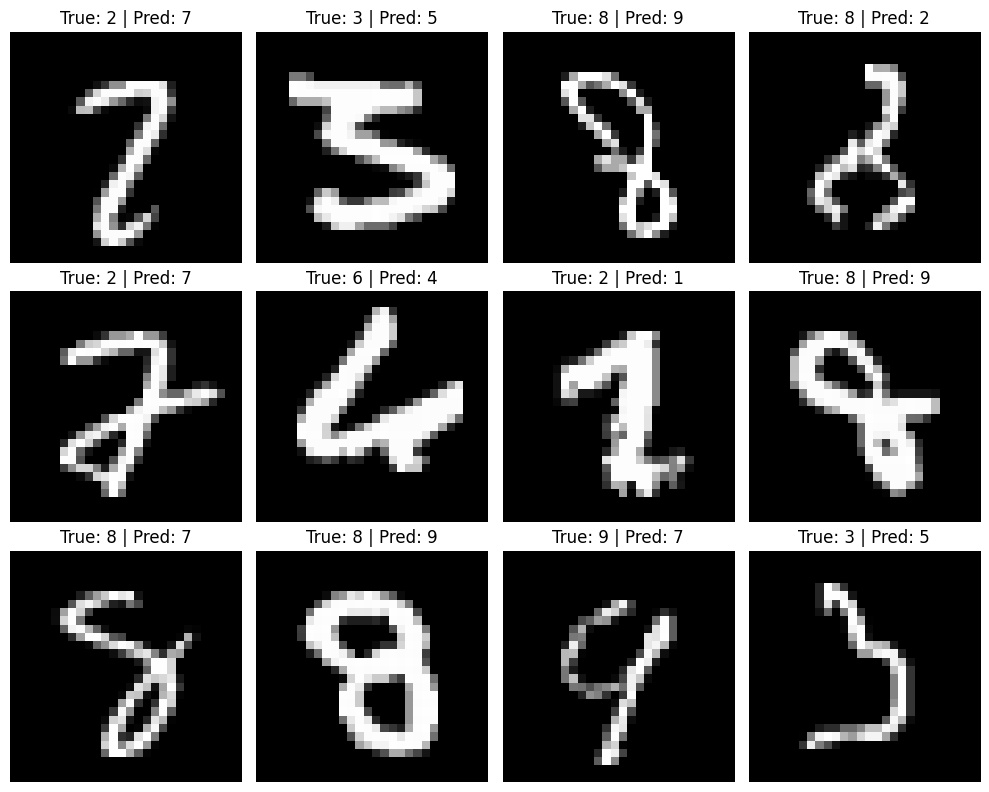

In [11]:
model.eval()

wrong_images = []
wrong_labels = []
wrong_predictions = []

with torch.no_grad():
    for images, labels in test_loader:

        outputs = model(images.to(device))
        predictions = outputs.argmax(dim=1).cpu()

        wrong_mask = predictions != labels

        wrong_images.extend(images[wrong_mask])
        wrong_labels.extend(labels[wrong_mask])
        wrong_predictions.extend(predictions[wrong_mask])

        if len(wrong_images) >= 12:
            break


fig, axes = plt.subplots(3, 4, figsize=(10, 8))

for i, ax in enumerate(axes.flat):

    image = wrong_images[i] * 0.3081 + 0.1307

    ax.imshow(image.squeeze(), cmap="gray")

    ax.set_title(
        f"True: {wrong_labels[i].item()} | "
        f"Pred: {wrong_predictions[i].item()}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

# 9. Comparative Insights: MNIST vs. CIFAR-10

### Key Technical Differences & Observations

| Feature / Metric | MNIST Implementation | CIFAR-10 Implementation |
| :--- | :--- | :--- |
| **Input Shape** | `(1, 28, 28)` (Grayscale) | `(3, 32, 32)` (RGB Color) |
| **Image Nature** | High-contrast handwritten digits (0–9) on black background | Complex real-world objects (animals, vehicles) with rich backgrounds |
| **Model Capacity** | Simple 2-block ConvNet | 3-block Deep ConvNet with Batch Normalization & Dropout |
| **Data Augmentation** | None required (basic pixel normalization) | `RandomCrop(32, padding=4)`, `RandomHorizontalFlip()` |
| **Regularization** | Standard `Adam` without explicit regularizers | `BatchNorm2d`, `Dropout(0.5)`, `weight_decay=1e-4` |
| **Convergence Rate** | Reaches **98.0%+** accuracy in just **3–5 epochs** | Requires **25–50+ epochs** to reach **85%+** accuracy |
| **Human vs CNN Perception** | Digits are clear to human eyes | 32x32 RGB images look pixelated to humans, but CNN filters extract robust micro-patterns |

### Core Takeaways
1. **Task Complexity:** MNIST is a simple, high-contrast benchmark where spatial patterns are straightforward. CIFAR-10 introduces spatial intra-class variation, background noise, and color complexity.
2. **Role of Regularization:** On simple datasets like MNIST, basic CNNs achieve >99% accuracy without regularization. For complex datasets like CIFAR-10, regularizers (`BatchNorm2d`, `Dropout`, `weight_decay`) are essential to prevent severe overfitting.
3. **Invariance:** Data augmentation (`RandomCrop`, `RandomHorizontalFlip`) forces the CIFAR-10 model to learn translation and orientation invariance, dramatically improving generalization on unseen test data.